# 第020单元 经验风险与泛化

## Goal
训练平均为何只是总体风险的替代？对8输入、二元噪声标签的已知总体，比较常数、阈值、查表模型的拟合与评价。先修018，不用梯度或框架。所有数据合成，精确总体风险仅供审计。

## Setup
从本单元目录重启内核，运行全部。图文只对应默认配置与固定手算表；第一格先检查输入和已保存结果，拒绝混用自定义结果。自定义脚本请另存。

In [1]:
from pathlib import Path
from fractions import Fraction as F
from itertools import product
import math,sys
from IPython.display import display,Image
from experiment import (risk,empirical_risk,fit,candidates,load_training,run,require_teaching_inputs)
require_teaching_inputs()
print("Python",sys.version.split()[0])

Python 3.12.14


## Steps
### 1 先确认目标总体
每个x等权，前半η=0.1、后半η=0.9。多数方向最优，仍有0.1噪声错误。

In [2]:
bayes=(0,0,0,0,1,1,1,1)
assert risk(bayes)==F(1,10)
assert risk((0,)*8)==F(1,2)
print("best population risk",risk(bayes))

best population risk 1/10


### 2 用80个原子独立核对全部规则
每个x对应10个等权标签机制编号，总计80个联合原子。

In [3]:
atoms=[(x,int(k<(1 if x<4 else 9))) for x in range(8) for k in range(10)]
for h in product((0,1),repeat=8):
    assert risk(h)==F(sum(h[x]!=y for x,y in atoms),80)
print("256 rules checked against 80 atoms")

256 rules checked against 80 atoms


### 3 三个ERM解
同一训练批，固定字典序并列规则，拟合不读取总体概率。

In [4]:
train=load_training()
models={k:fit(k,train) for k in ("constant","threshold","lookup")}
for k,h in models.items():
    print(k,h,"train",empirical_risk(h,train),"population",risk(h))
assert empirical_risk(models["lookup"],train)==0
assert risk(models["lookup"])==F(1,2)

constant (0, 0, 0, 0, 0, 0, 0, 0) train 1/2 population 1/2
threshold (0, 1, 1, 1, 1, 1, 1, 1) train 1/4 population 2/5
lookup (0, 1, 0, 0, 1, 0, 0, 0) train 0 population 1/2


### 4 看见训练点之外的预测
离散类别间的连线只辅助阅读，未定义连续输入。

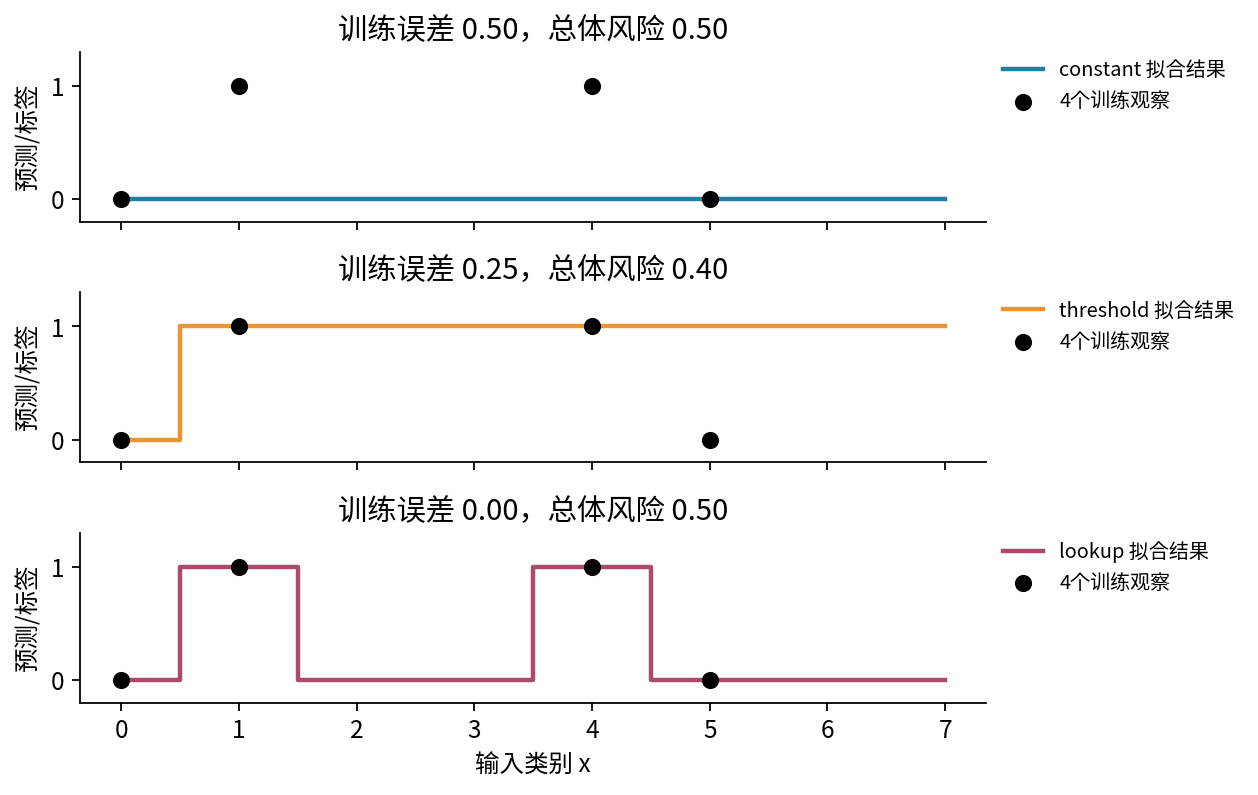

In [5]:
display(Image(filename="figures/02_three_fits.png",width=720))

### 5 经验优化差与总体差
训练更差的h4在此总体更好，仅证明两种目标不同。

In [6]:
empirical_gap=empirical_risk(bayes,train)-empirical_risk(models["threshold"],train)
population_gap=risk(bayes)-risk(models["threshold"])
assert empirical_gap==F(1,4) and population_gap==F(-3,10)
print("empirical gap",empirical_gap,"population change",population_gap)

empirical gap 1/4 population change -3/10


### 6 同时控制全部候选
本例的统一偏差很大，因此上界虽正确却无实用精度。

In [7]:
eps=max(abs(empirical_risk(h,train)-risk(h)) for h in candidates("threshold"))
assert eps==F(11,20)
print("epsilon_D",eps,"ERM excess bound",2*eps,"actual excess",risk(models["threshold"])-F(1,10))

epsilon_D 11/20 ERM excess bound 11/10 actual excess 3/10


### 7 单样本选择效应
固定常数规则评价无偏，先观察再选匹配标签会使训练分数过分乐观。

In [8]:
for y in (0,1):
    h=fit("constant",[(0,y)])
    assert empirical_risk(h,[(0,y)])==0 and risk(h)==F(1,2)
print("selected training error=0, population error=1/2")

selected training error=0, population error=1/2


### 8 实际执行800次重复
每次新生成训练、验证、测试三批。只按验证选择，冻结后评价测试；结果写notebook_outputs。

In [9]:
fixed,summary=run(Path("notebook_outputs"))
for r in summary:
    print(r["n"],r["class"],"train",round(r["mean_train_risk"],6),"population",round(r["mean_population_risk"],6))

8 constant train 0.367812 population 0.5
8 threshold train 0.0825 population 0.18675
8 lookup train 0.056719 population 0.29225
8 validation_selected train 0.077188 population 0.18475
32 constant train 0.429102 population 0.5
32 threshold train 0.095156 population 0.109375
32 lookup train 0.091797 population 0.131375
32 validation_selected train 0.094883 population 0.109
128 constant train 0.464346 population 0.5
128 threshold train 0.099854 population 0.100125
128 lookup train 0.099854 population 0.100125
128 validation_selected train 0.099854 population 0.100125


### 9 容量与样本量
左图是训练风险，右图是总体风险再对随机训练集取平均；不能把左图排序当右图保证。

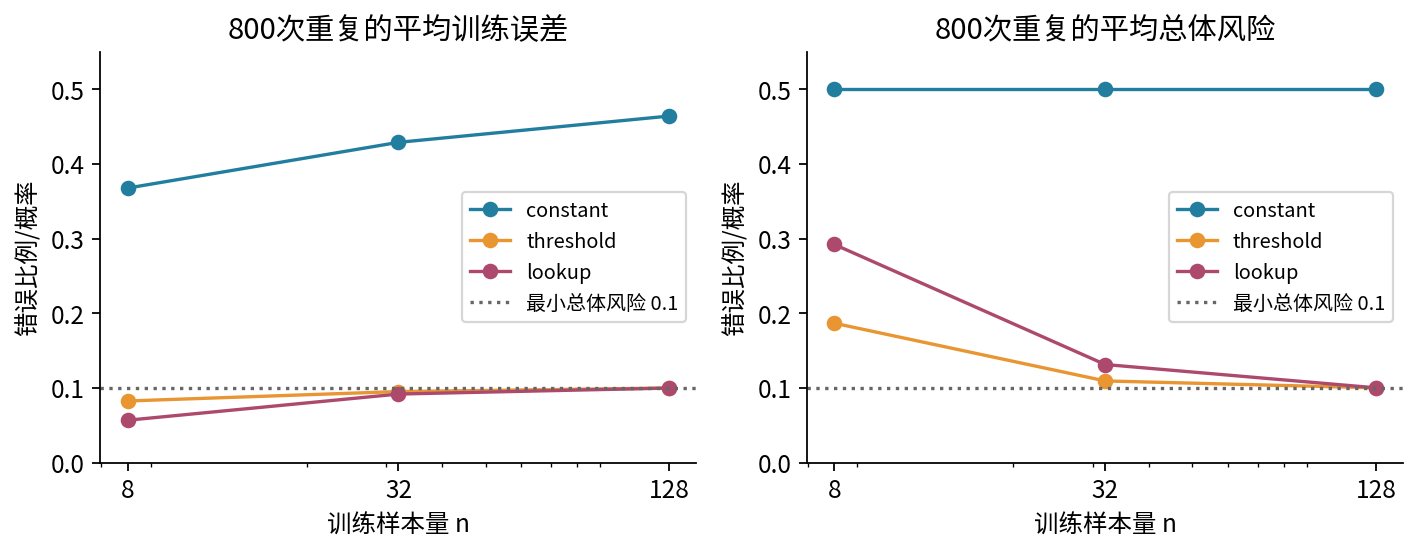

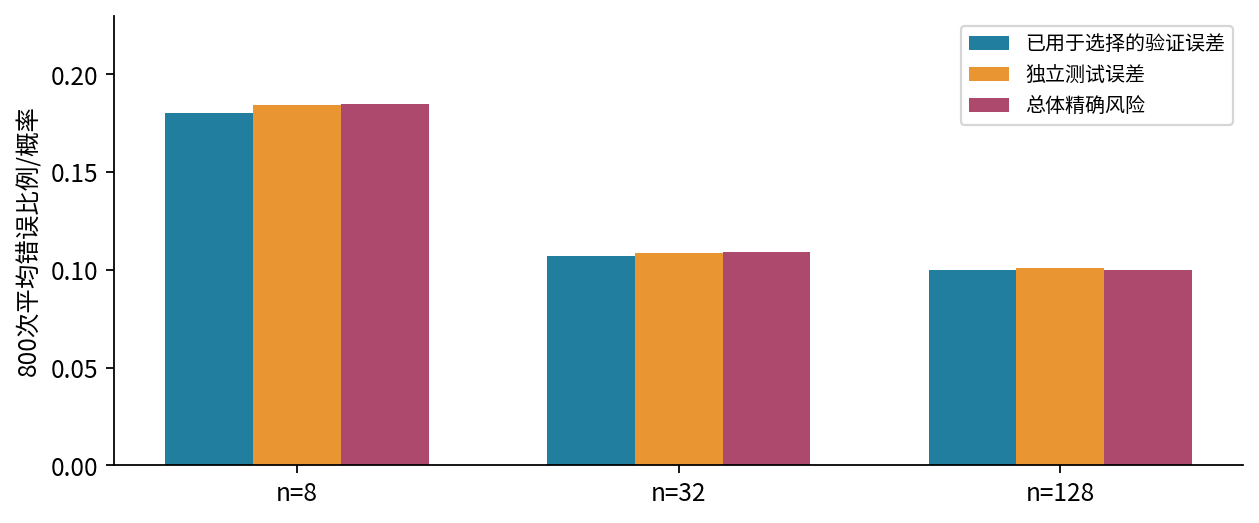

In [10]:
display(Image(filename="figures/05_sample_capacity.png",width=740))
display(Image(filename="figures/06_selection_test.png",width=740))

### 10 精确平方损失分解
仅在x=4，训练标签与新标签独立，各自P(Y=1)=0.9。此处不是0–1损失。

In [11]:
joint=[(a,b,F((9 if a else 1)*(9 if b else 1),100)) for a,b in product((0,1),repeat=2)]
one=sum((a-b)**2*p for a,b,p in joint)
constant=sum((F(1,2)-b)**2*p for a,b,p in joint)
assert one==F(9,50) and constant==F(1,4)
print("one-label risk",one,"constant-half risk",constant)

one-label risk 9/50 constant-half risk 1/4


### 11 改变目标分布
先冻结规则。第一式改条件机制，第二式只改输入质量，均没有重新训练。

In [12]:
assert risk(bayes,(9,9,9,9,1,1,1,1))==F(9,10)
assert risk(models["threshold"],weights=(1,3,3,3,1,1,1,1))==F(43,70)
print("reversed conditional risk=9/10; changed input masses risk=43/70")

reversed conditional risk=9/10; changed input masses risk=43/70


## Checks
### 12 非法输入必须拒绝
布尔值不能充当分类标签。完整测试还检查CSV重复列与旧输出保护。

In [13]:
try:
    fit("lookup",[(0,True)])
except ValueError as error:
    print("rejected",error)
else:
    raise AssertionError("boolean label must be rejected")

rejected y: integer in [0,1] required


### 13 脚本与Notebook相符
比较全部4个产物。先核对配置与输入，再讨论是否同一次实验。

In [14]:
for name in ("results.json","trials.csv","summary.csv","environment.json"):
    assert (Path("outputs")/name).read_bytes()==(Path("notebook_outputs")/name).read_bytes()
print("4 output files are byte-identical")

4 output files are byte-identical


## Next Steps
固定四条数据的查表训练误差0，总体风险0.5；阈值训练0.25，总体0.4，故经验目标不是总体保证。完成正文12题，写清训练、选择与评价依赖。

实际执行采用真实InProcessKernel；未测全新Anaconda、浏览器UI、socket内核或跨平台安装。小合成实验不证明真实模型泛化。来源见lecture.md与source-checks.json。